In [1]:
import numpy as np
from torchvision.datasets import CocoDetection
import datetime
import os
from tqdm import tqdm
import matplotlib.pyplot as plt
import pandas as pd
import sys 
sys.path.append("/home/tyfei/cyroem")
import utils
import torch
import importlib 
import json
import modules
importlib.reload(utils)
importlib.reload(modules)
import torchmetrics
import data

import pycocotools.coco
import pycocotools.mask
import torchvision.transforms.v2 as transforms
from transformers import DetrConfig, DetrForObjectDetection, DetrImageProcessor, DetrForSegmentation, ConditionalDetrForObjectDetection,ConditionalDetrConfig,ConditionalDetrForSegmentation

/home/feity/anaconda3/envs/pytorch/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## test dataset for 11 length

In [18]:
path = "/data/transformer_project/transforemer_model/train_data/training/results/deformable/pretrain_11"
with open(os.path.join(path, "config.json"), "r") as f:
    configs = json.load(f)
ds = data.get_stage1_dataset(configs)

loading annotations into memory...
Done (t=0.97s)
creating index...
index created!
loading annotations into memory...
Done (t=0.13s)
creating index...
index created!


In [16]:
tds = ds.train_dataloader()
tds = tds.dataset
len(tds)

7330

In [6]:
tds.coco.loadImgs(101)[0]["file_name"]

'sllt0093_9/minmax_0.npy'

In [22]:
model = modules.VitForMask(sigmoid=False) 
d1 = torch.randn((2, 11, 512, 512)) 
t = torch.randn((2, 272)) 
b = torch.tensor(((.5, .5, .1, .1), (.4, .4, .1, .1)))
res = model(d1, t, b)

/home/feity/anaconda3/envs/pytorch/lib/python3.12/site-packages/torch/nn/modules/transformer.py:307: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(f"enable_nested_tensor is True, but self.use_nested_tensor is False because {why_not_sparsity_fast_path}")


In [23]:
res.shape

torch.Size([2, 5, 512, 512])

In [3]:
t = ds.train_dataloader()
d = t.dataset
d[0]["pixel_values"].shape

torch.Size([11, 512, 512])

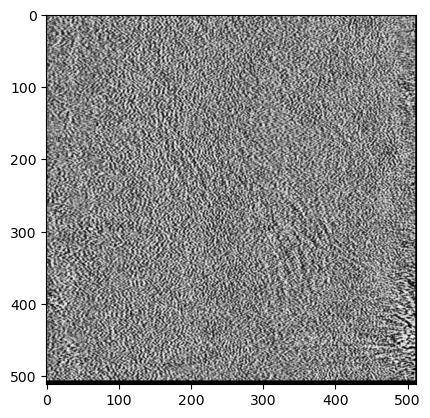

In [4]:
d = d[0]["pixel_values"].numpy() 
plt.imshow(d[2], cmap="gray")

In [14]:
import skimage.exposure

In [19]:
model = utils.getModel(configs)

model at stage  stage 1


/home/feity/anaconda3/envs/pytorch/lib/python3.12/site-packages/torch/nn/modules/transformer.py:307: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(f"enable_nested_tensor is True, but self.use_nested_tensor is False because {why_not_sparsity_fast_path}")
/home/feity/cryoem/utils.py:810: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded v

incompatible parameters ['model.model.backbone.conv_encoder.model.conv1.weight']
finish loading parameters


In [20]:
model

DetrModel(
  (model): DeformableDetrForObjectDetection(
    (model): DeformableDetrModel(
      (backbone): DeformableDetrConvModel(
        (conv_encoder): DeformableDetrConvEncoder(
          (model): FeatureListNet(
            (conv1): Conv2d(11, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
            (bn1): DeformableDetrFrozenBatchNorm2d()
            (act1): ReLU(inplace=True)
            (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
            (layer1): Sequential(
              (0): Bottleneck(
                (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
                (bn1): DeformableDetrFrozenBatchNorm2d()
                (act1): ReLU(inplace=True)
                (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
                (bn2): DeformableDetrFrozenBatchNorm2d()
                (drop_block): Identity()
                (act2): ReLU(inplace=Tr

In [12]:
sd = model.state_dict()
torch.save(sd, "/data/transformer_project/transforemer_model/train_data/training/results/deformable/pretrain_11/base.pth")

In [25]:
model = ConditionalDetrForObjectDetection.from_pretrained(
                    configs["model"]["pretrained"], ignore_mismatched_sizes=True, num_channels=3
                )
model

ConditionalDetrForObjectDetection(
  (model): ConditionalDetrModel(
    (backbone): ConditionalDetrConvModel(
      (conv_encoder): ConditionalDetrConvEncoder(
        (model): FeatureListNet(
          (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
          (bn1): ConditionalDetrFrozenBatchNorm2d()
          (act1): ReLU(inplace=True)
          (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
          (layer1): Sequential(
            (0): Bottleneck(
              (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
              (bn1): ConditionalDetrFrozenBatchNorm2d()
              (act1): ReLU(inplace=True)
              (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
              (bn2): ConditionalDetrFrozenBatchNorm2d()
              (drop_block): Identity()
              (act2): ReLU(inplace=True)
              (aa): Identity()
              (

### test stage1 + 2 effect

In [3]:
model = utils.loadModel("/data/transformer_project/transforemer_model/train_data/training/results/conditional_detr/whole_Unet5_0.8", "last.ckpt")

Some weights of ConditionalDetrForObjectDetection were not initialized from the model checkpoint at microsoft/conditional-detr-resnet-50 and are newly initialized because the shapes did not match:
- class_labels_classifier.bias: found shape torch.Size([91]) in the checkpoint and torch.Size([5]) in the model instantiated
- class_labels_classifier.weight: found shape torch.Size([91, 256]) in the checkpoint and torch.Size([5, 256]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/home/feity/anaconda3/envs/pytorch/lib/python3.12/site-packages/torch/nn/modules/transformer.py:307: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(f"enable_nested_tensor is True, but self.use_nested_tensor is False because {why_not_sparsity_fast_path}")


model at stage  stage 1 + 2 + 3


/home/feity/cryoem/utils.py:807: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  t = torch.load(configs["model"]["load"], map_location="cpu")


incompatible parameters ['model.class_labels_classifier.weight', 'model.class_labels_classifier.bias', 'additional_input_layer.layer1.weight', 'additional_input_layer.layer1.bias', 'additional_input_layer.layer2.weight', 'additional_input_layer.layer2.bias', 'gnn.conv1.lin_l.weight', 'gnn.conv1.lin_l.bias', 'gnn.conv1.lin_r.weight', 'gnn.conv2.lin_l.weight', 'gnn.conv2.lin_l.bias', 'gnn.conv2.lin_r.weight', 'gnn.conv3.lin_l.weight', 'gnn.conv3.lin_l.bias', 'gnn.conv3.lin_r.weight', 'gnn.cls_head.0.weight', 'gnn.cls_head.0.bias', 'gnn.cls_head.2.weight', 'gnn.cls_head.2.bias', 'gnn.box_head.0.weight', 'gnn.box_head.0.bias', 'gnn.box_head.2.weight', 'gnn.box_head.2.bias', 'gnn.edge_head.0.weight', 'gnn.edge_head.0.bias', 'gnn.edge_head.2.weight', 'gnn.edge_head.2.bias', 'gnn.edge_head.4.weight', 'cri.weight', 'mask_head.inc.double_conv.0.weight', 'mask_head.inc.double_conv.1.weight', 'mask_head.inc.double_conv.1.bias', 'mask_head.inc.double_conv.3.weight', 'mask_head.inc.double_conv.4.we

/home/feity/cryoem/utils.py:845: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(os.path.join(path, checkpoint), map_location="cpu")["state_dict"]


incompatible parameters ['gnn.pe', 'mask_head.inc.double_conv.0.weight']
finish loading parameters


In [10]:
t = torch.randn((2, 3, 800, 800))
model.model.model.backbone.conv_encoder.model.forward(t)[0].shape

torch.Size([2, 256, 200, 200])

In [42]:
nms = {"ribo":0.2, "microtubule":0.5, "nucleus":0.2, "endoplasmic_reticulum_or_Golgi":0.6, "mitochondria":0.2, "None":1.2}
for i in os.listdir("/data/transformer_project/transforemer_model/test_data/dxd20240920/tomo/"):
    if not os.path.isdir(os.path.join("/data/transformer_project/transforemer_model/test_data/dxd20240920/tomo/", i)):
        continue
    file = i 
    graph = torch.load("/data/transformer_project/transforemer_model/test_data/dxd20240920/tomo/%s_stage2dataset_stage12_515.pkl"%file) 
    retdict = torch.load("/data/transformer_project/transforemer_model/test_data/dxd20240920/tomo/%s_stage2dict_stage12_515.pkl"%file)
    model = model.eval()
    model.stage = "stage 2"
    with torch.no_grad():
        res = model(graph.x, graph.edge_index)
    z = graph.x[:, [0]]
    prob = torch.softmax(res["predict"], 1)
    pred_boxes = res["box"]
    # pred_boxes = utils.convertBoxes(pred_boxes)
    # z.shape, pred_boxes.shape, prob.shape
    df = torch.cat([z, pred_boxes, prob], 1)
    df = df.detach().numpy()
    df = pd.DataFrame(df, columns=["z", "x", "y", "w", "h", "ribo", "microtubule", "nucleus", "endoplasmic_reticulum_or_Golgi", "mitochondria", "None"])
    subdf = df[["ribo", "microtubule", "nucleus", "endoplasmic_reticulum_or_Golgi", "mitochondria", "None"]]
    v = subdf.values 
    v = v > np.array([0.75, 0.5, 0.5, 0.5, 0.5, 1.2]) 
    v = v.any(axis=1) 
    df["max"] = subdf.max(axis=1)
    df["largest"] = subdf.idxmax(axis=1)
    df["prob"] = v  
    alldfs = []
    for i, subdf in df.groupby(["z", "largest"]):
        # print(subdf.head())
        if i[1] == "None":
            continue
        keep = utils.bbnms(nms[i[1]], utils.convertBoxes(torch.tensor(subdf[["x", "y", "w", "h"]].values)), torch.tensor(subdf["max"].values), subdf["largest"].values)
        subdf["bbnms"] = False
        subdf.iloc[keep.numpy(), -1] = True
        alldfs.append(subdf)
        
    df = pd.concat(alldfs)
    df["final"] = df["bbnms"] & df["prob"]
    subdf = df[df["largest"] == "ribo"]
    subdf = subdf[subdf["final"]]
    df = pd.concat(alldfs)
    
    hdb = DBSCAN(min_samples=2, eps = 0.3, metric='precomputed')
    iou = utils.get_iou(subdf[["x", "y", "w", "h"]].values)
    iou = 1 - iou
    mask = subdf["z"].values 
    mask = mask[:, None] == mask[None, :]
    iou[mask] = 2
    mask = subdf["z"].values 
    dis_penalty = np.abs(mask[:, None] - mask[None, :])
    iou = iou + dis_penalty
    hdb.fit(iou)  
    subdf["label"] = hdb.labels_
    # np.unique(hdb.labels_).tolist()
    subdf.to_csv("./res/%s.csv"%file)

    

/tmp/ipykernel_1200772/3322434999.py:6: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  graph = torch.load("/data/transformer_project/transforemer_model/test_data/dxd20240920/

NameError: name 'DBSCAN' is not defined

In [77]:
file="sllt0039_9.pkl"
graph = torch.load("/data/transformer_project/transforemer_model/train_data/training/data/stage2/conditional_"+file.split(".")[0]+"_stage2dataset_stage12_530.pkl")
retdict = torch.load("/data/transformer_project/transforemer_model/train_data/training/data/stage2/conditional_"+file.split(".")[0]+"_stage2dict_stage12_530.pkl")
# file = "24092025_9"
# graph = torch.load("/data/transformer_project/transforemer_model/test_data/dxd20240920/tomo/%s_stage2dataset_stage12_515.pkl"%file) 
# retdict = torch.load("/data/transformer_project/transforemer_model/test_data/dxd20240920/tomo/%s_stage2dict_stage12_515.pkl"%file)
# model = utils.loadModel("/data/transformer_project/transforemer_model/train_data/training/results/deformable/final/fold4", "epoch=49-total_validate_auroc=0.7751-total_validate_loss=0.8721.ckpt")
# model = utils.loadModel("/data/transformer_project/transforemer_model/train_data/training/results/deformable/all_try_pos", "last.ckpt")
# model = utils.loadModel("/data/transformer_project/transforemer_model/train_data/training/results/deformable/fold1_try12", "epoch=23-total_validate_loss=0.5593.ckpt")
# model = utils.loadModel("/data/transformer_project/transforemer_model/train_data/training/results/deformable/fold1_stage2_change_SAGE2", "epoch=21-validate_loss=0.9872-validate_auroc=0.8372.ckpt")
# model = utils.loadModel("/data/transformer_project/transforemer_model/train_data/training/results/deformable/final/fold1_T", "last.ckpt")

/tmp/ipykernel_1200772/2433370424.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  graph = torch.load("/data/transformer_project/transforemer_model/train_data/training/da

In [78]:
graph

Data(x=[8400, 266], edge_index=[2, 203988], y=[8400], box_masks=[8400], boxes=[8400, 4], edge_label=[203988], sample_mapping=[8400])

In [79]:
model.stage = "stage 2"
model = model.eval()
with torch.no_grad():
    res = model(graph.x, graph.edge_index)
res.keys()

dict_keys(['predict', 'box', 'edge', 'embeddings'])

In [91]:
z = graph.x[:, [0]]
prob = torch.softmax(res["predict"], 1)
pred_boxes = res["box"]
# pred_boxes = utils.convertBoxes(pred_boxes)
# z.shape, pred_boxes.shape, prob.shape
df = torch.cat([z, pred_boxes, prob], 1)
df = df.detach().numpy()
df = pd.DataFrame(df, columns=["z", "x", "y", "w", "h", "ribo", "microtubule", "nucleus", "endoplasmic_reticulum_or_Golgi", "mitochondria", "None"])
subdf = df[["ribo", "microtubule", "nucleus", "endoplasmic_reticulum_or_Golgi", "mitochondria", "None"]]
v = subdf.values 
v = v > np.array([0.75, 0.5, 0.3, 0.5, 0.5, 1.2]) 
v = v.any(axis=1) 
df["max"] = subdf.max(axis=1)
df["largest"] = subdf.idxmax(axis=1)
df["prob"] = v
df

,z,x,y,w,h,ribo,microtubule,nucleus,endoplasmic_reticulum_or_Golgi,mitochondria,None,max,largest,prob
0,0.22,0.745119,0.816876,0.068198,0.143489,0.000074,1.478904e-08,8.283964e-05,3.387390e-06,1.388584e-05,0.999826,0.999826,None,False
1,0.22,0.322405,0.053303,0.029088,0.016451,0.000613,8.731780e-09,4.158489e-07,7.999999e-08,1.177585e-08,0.999387,0.999387,None,False
2,0.22,0.843370,0.459931,0.056461,0.089543,0.000178,5.429898e-09,3.694460e-05,7.641197e-07,1.641956e-06,0.999783,0.999783,None,False
3,0.22,0.127475,0.172376,0.024554,0.023790,0.000975,1.090404e-09,6.614851e-09,8.624920e-10,4.544491e-11,0.999025,0.999025,None,False
4,0.22,0.426068,0.656806,0.023137,0.024300,0.001053,3.785751e-08,2.973719e-06,3.164920e-07,8.969889e-08,0.998943,0.998943,None,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8395,0.80,0.575621,0.227737,0.022597,0.020340,0.000722,1.171529e-07,4.684000e-06,2.713061e-06,1.338924e-06,0.999269,0.999269,None,False
8396,0.80,0.347394,0.143716,0.033296,0.020937,0.000022,3.424763e-11,9.250190e-08,2.165657e-09,1.240020e-09,0.999978,0.999978,None,False
8397,0.80,0.273949,0.269425,0.029101,0.027144,0.000006,5.121861e-11,3.253064e-06,1.848406e-08,2.835193e-07,0.999990,0.999990,None,False
8398,0.80,0.901221,0.454279,0.180064,0.113220,0.002600,1.533119e-04,2.368867e-02,1.498271e-02,6.273132e-02,0.895844,0.895844,None,False


In [92]:
df["largest"].value_counts()

largest
None                              7500
ribo                               592
mitochondria                       103
endoplasmic_reticulum_or_Golgi      99
microtubule                         74
nucleus                             32
Name: count, dtype: int64

In [93]:
alldfs = []
for i, subdf in df.groupby(["z", "largest"]):
    # print(subdf.head())
    if i[1] == "None":
        continue
    keep = utils.bbnms(nms[i[1]], utils.convertBoxes(torch.tensor(subdf[["x", "y", "w", "h"]].values)), torch.tensor(subdf["max"].values), subdf["largest"].values)
    subdf["bbnms"] = False
    subdf.iloc[keep.numpy(), -1] = True
    alldfs.append(subdf)

In [94]:
df = pd.concat(alldfs)
df["final"] = df["bbnms"] & df["prob"]
np.sum(df["final"])

564

In [95]:
subdf = df

In [96]:
import numpy as np
from sklearn.cluster import DBSCAN
from sklearn.datasets import load_digits
from scipy.spatial.distance import pdist, squareform

hdb = DBSCAN(min_samples=2, eps = 0.4, metric='precomputed')
iou = utils.get_iou(subdf[["x", "y", "w", "h"]].values)
iou = 1 - iou
mask = subdf["z"].values 
mask = mask[:, None] == mask[None, :]
iou[mask] = 2
mask = subdf["z"].values 
dis_penalty = np.abs(mask[:, None] - mask[None, :])
iou = iou + dis_penalty
hdb.fit(iou)  

subdf["label"] = hdb.labels_
np.unique(hdb.labels_).tolist()
# hdb.fit(X)
# hdb.labels_.shape == (X.shape[0],)
# np.unique(hdb.labels_).tolist()

[-1,
 0,
 1,
 2,
 3,
 4,
 5,
 6,
 7,
 8,
 9,
 10,
 11,
 12,
 13,
 14,
 15,
 16,
 17,
 18,
 19,
 20,
 21,
 22,
 23,
 24]

In [97]:
subdf.to_csv("./res/%s_all.csv"%file.split(".")[0])

In [ ]:
for take in range(100):
    need = [] 
    for i in retdict["sample_mapping"]:
        if retdict["sample_mapping"][i] == take and i in subdf.index:
            need.append(i)
            
    img = retdict["images"][take]
    subdf2 = subdf.loc[need]
    subdf2 = subdf2[subdf2["final"]]
    # 
    subdf2["label"] = subdf2["label"].astype("str") 
    subdf2 = subdf2[subdf2["label"] != -1]
    bboxes = subdf2[["x", "y", "w", "h"]].values
    bboxes = utils.convertBoxes(torch.tensor(bboxes))
    bboxes = torch.tensor(bboxes)*torch.tensor([img.shape[1], img.shape[2], img.shape[1], img.shape[2]])
    # bboxes, img.shape
    labels = {"bboxes": bboxes, "labels": subdf2["label"].values} 
    utils.drawannotation(img, labels, font_size=100)
    plt.savefig(f"./figures/24092002_9/{take}_all.png", dpi=300)
    plt.close()
    
    subdf2 = subdf2[subdf2["label"] != "-1"]
    bboxes = subdf2[["x", "y", "w", "h"]].values
    bboxes = utils.convertBoxes(torch.tensor(bboxes))
    bboxes = torch.tensor(bboxes)*torch.tensor([img.shape[1], img.shape[2], img.shape[1], img.shape[2]])
    # bboxes, img.shape
    labels = {"bboxes": bboxes, "labels": subdf2["label"].values} 
    utils.drawannotation(img, labels, font_size=100)
    plt.savefig(f"./figures/24092002_9/{take}_refined.png", dpi=300)
    plt.close()

/tmp/ipykernel_2341111/1270707860.py:15: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  bboxes = torch.tensor(bboxes)*torch.tensor([img.shape[1], img.shape[2], img.shape[1], img.shape[2]])
/home/feity/cryoem/utils.py:102: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  image = torch.tensor(image * 255).type(torch.uint8)
/home/feity/cryoem/utils.py:113: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  annotated_tensor = torch.tensor(annotated_tensor, dtype=torch.uint8)
/home/feity/anaconda3/envs/pytorch/lib/python3.12/site-packages/torchvision/u

In [98]:
take = 10
need = []
for i in retdict["sample_mapping"]:
    if retdict["sample_mapping"][i] == take and i in subdf.index:
        need.append(i)
        
img = retdict["images"][take]
subdf2 = subdf.loc[need]
subdf2 = subdf2[subdf2["final"]]
# 
subdf2["label"] = subdf2["label"].astype("str")
# subdf2

/tmp/ipykernel_1200772/2467981457.py:4: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  bboxes = torch.tensor(bboxes)*torch.tensor([img.shape[1], img.shape[2], img.shape[1], img.shape[2]])
/home/feity/cryoem/utils.py:113: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  image = torch.tensor(image * 255).type(torch.uint8)
/home/feity/cryoem/utils.py:124: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  annotated_tensor = torch.tensor(annotated_tensor, dtype=torch.uint8)
/home/feity/anaconda3/envs/pytorch/lib/python3.12/site-packages/torchvision/ut

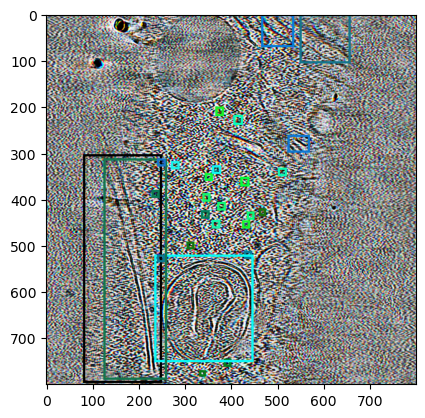

In [99]:
subdf2 = subdf2[subdf2["label"] != -1]
bboxes = subdf2[["x", "y", "w", "h"]].values
bboxes = utils.convertBoxes(torch.tensor(bboxes))
bboxes = torch.tensor(bboxes)*torch.tensor([img.shape[1], img.shape[2], img.shape[1], img.shape[2]])
# bboxes, img.shape
labels = {"bboxes": bboxes, "labels": subdf2["label"].values} 
utils.drawannotation(img, labels, font_size=100)

/tmp/ipykernel_1200772/969131642.py:4: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  bboxes = torch.tensor(bboxes)*torch.tensor([img.shape[1], img.shape[2], img.shape[1], img.shape[2]])
/home/feity/cryoem/utils.py:113: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  image = torch.tensor(image * 255).type(torch.uint8)
/home/feity/cryoem/utils.py:124: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  annotated_tensor = torch.tensor(annotated_tensor, dtype=torch.uint8)
/home/feity/anaconda3/envs/pytorch/lib/python3.12/site-packages/torchvision/uti

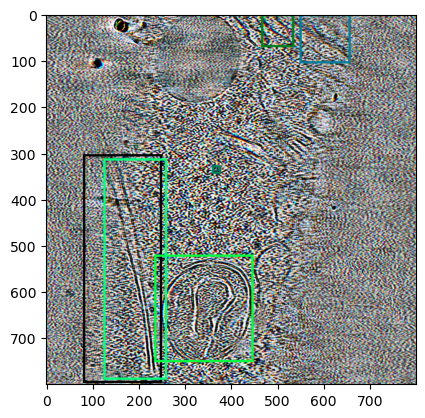

: 

In [ ]:
subdf2 = subdf2[subdf2["label"] != "-1"]
bboxes = subdf2[["x", "y", "w", "h"]].values
bboxes = utils.convertBoxes(torch.tensor(bboxes))
bboxes = torch.tensor(bboxes)*torch.tensor([img.shape[1], img.shape[2], img.shape[1], img.shape[2]])
# bboxes, img.shape
labels = {"bboxes": bboxes, "labels": subdf2["label"].values} 
utils.drawannotation(img, labels, font_size=100)

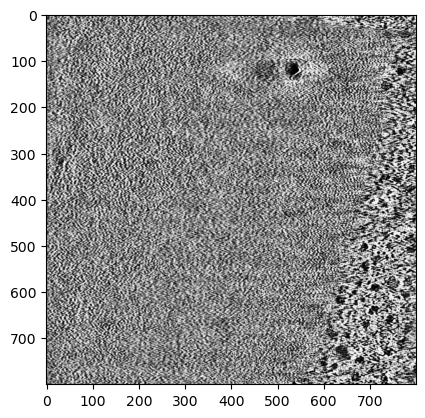

In [ ]:
plt.imshow(img[1], cmap="gray")

In [ ]:
subdf2

,z,x,y,w,h,ribo,microtubule,nucleus,endoplasmic_reticulum_or_Golgi,mitochondria,None,max,largest,prob,bbnms,final,label
6066,0.84,0.621520,0.838383,0.019837,0.020880,0.785204,0.001625,2.824324e-07,0.000043,1.558031e-10,0.213128,0.785204,ribo,True,True,True,475
6073,0.84,0.967220,0.442489,0.023320,0.024728,0.887856,0.000583,6.838639e-08,0.000013,3.219544e-11,0.111548,0.887856,ribo,True,True,True,476
6092,0.84,0.675093,0.439033,0.021656,0.020449,0.834764,0.002318,1.460615e-07,0.000048,8.038625e-11,0.162870,0.834764,ribo,True,True,True,494
6093,0.84,0.794837,0.791797,0.022621,0.021973,0.793902,0.000350,6.124585e-08,0.000009,1.718937e-11,0.205739,0.793902,ribo,True,True,True,495
6100,0.84,0.854380,0.929798,0.025175,0.023681,0.796247,0.000273,5.274387e-08,0.000007,1.078555e-11,0.203474,0.796247,ribo,True,True,True,483
6106,0.84,0.827862,0.960362,0.021842,0.024442,0.762952,0.000358,1.079699e-07,0.000013,3.217010e-11,0.236677,0.762952,ribo,True,True,True,501
6112,0.84,0.632787,0.910618,0.020579,0.021584,0.756510,0.001099,3.666862e-07,0.000038,2.009296e-10,0.242353,0.756510,ribo,True,True,True,484
6128,0.84,0.768183,0.421474,0.022728,0.021411,0.799948,0.001493,3.200198e-07,0.000040,2.058290e-10,0.198519,0.799948,ribo,True,True,True,480
6129,0.84,0.775182,0.847899,0.024014,0.024389,0.862001,0.000400,4.165989e-08,0.000008,1.306950e-11,0.137590,0.862001,ribo,True,True,True,487
6133,0.84,0.767497,0.770026,0.022771,0.022569,0.815341,0.000569,1.248149e-07,0.000015,5.055730e-11,0.184074,0.815341,ribo,True,True,True,498


In [ ]:
tomo=[] 
memb=[]
ribo = [] 
ribo_mask = []
name = []
for k in ["sull20241102_AA", "20241102_BSA1_tilt", "sull20240525_tilt", "sull20241102_AA", "sull20241102_BSA2", "sull20241122_AA", "sull20241203_rest", "zhaoxs20240805_0821_denoised", "zhaoxs20240901", "zhaoxs20240920"]:
    for i in os.listdir("/mnt/panbz/lab/transforemer_model/pretrain_data/%s/tomo/"%k):
        if not i.endswith(".mrc"):
            continue
        target = i[:i.find(".")]
        tomo.append(os.path.join("/mnt/panbz/lab/transforemer_model/pretrain_data/%s/tomo/"%k, i))
        ribo.append("/mnt/panbz/lab/transforemer_model/pretrain_data/%s/ribo/cor_done.star"%k)
        ribo_mask.append(target)
        if target in name:
            name.append(target+"(2)")
        else:
            name.append(target)
        for j in os.listdir("/mnt/panbz/lab/transforemer_model/pretrain_data/%s/memb"%k):
            if target in j:
                memb.append(os.path.join("/mnt/panbz/lab/transforemer_model/pretrain_data/%s/memb"%k, j))
                break  
    print(k)
    df_targets = pd.DataFrame({"tomo":tomo, "memb":memb, "ribo":ribo, "ribo_mask":ribo_mask, "name":name})

sull20241102_AA
20241102_BSA1_tilt
sull20240525_tilt
sull20241102_AA
sull20241102_BSA2
sull20241122_AA
sull20241203_rest
zhaoxs20240805_0821_denoised
zhaoxs20240901
zhaoxs20240920


In [ ]:
a, b = np.unique(df_targets["name"], return_counts=True)
a[b.argsort()]

array(['slltr0033_9', 'slltr0022_9', 'slltr0023_9', 'slltr0024_9',
       'slltr0025_9', 'slltr0026_9', 'slltr0027_9', 'slltr0028_9',
       'slltr0029_9', 'slltr0030_9', 'slltr0031_9', 'slltr0032_9',
       'slltr0021_9', 'slltr0034_9', 'slltr0035_9', 'slltr0036_9',
       'slltr0037_9', 'slltr0038_9', 'slltr0039_9', 'slltr0040_9',
       'slltr0041_9', 'slltr0042_9', 'slltr0043_9', 'slltr0010_9',
       'slltb0040_9', 'slltb0041_9', 'slltr0001_9', 'slltr0002_9',
       'slltr0003_9', 'slltr0004_9', 'slltr0005_9', 'slltr0006_9',
       'slltr0007_9', 'slltr0008_9', 'slltr0009_9', 'slltr0044_9',
       'slltr0011_9', 'slltr0012_9', 'slltr0013_9', 'slltr0014_9',
       'slltr0015_9', 'slltr0016_9', 'slltr0017_9', 'slltr0018_9',
       'slltr0019_9', 'slltr0020_9', 'sll_0013_9', 'zxs_0053_9',
       'zxs_0054_9', 'zxs_0055_9', 'zxs_0056_9', 'zxs_0057_9',
       'zxs_0058_9', 'zxs_0059_9', 'zxs_0070_9', 'sll_0009_9',
       'sll_0011_9', 'sll_0012_9', 'zxs_0052_9', 'sll_0015_9',
       's

In [ ]:
len(np.unique(df["name"]))

In [ ]:
# def loadModel(path, checkpoint="last.ckpt"):
#     with open(os.path.join(path, "config.json"), "r") as f:
#         configs = json.load(f)

#     model = getModel(configs)

#     ckpt = torch.load(os.path.join(path, checkpoint))["state_dict"]
#     need_del = []
#     p = [j for j, _ in model.named_parameters()]
#     for i in ckpt:
#         if i not in p or ckpt[i].shape != model.state_dict()[i].shape:
#             need_del.append(i)
#     for i in need_del:
#         del ckpt[i]
#     print(need_del)
#     model.load_state_dict(ckpt, strict=False)

#     return model

### test dataset

In [ ]:
dfs = {}
for i in ["TS_005.pkl", "TS_023.pkl", "TS_031.pkl", "sllt0039_9.pkl", "sllt0051_9.pkl", "sllt0081_9.pkl"]:
    dataset = modules.CocoTraverse("/data/transformer_project/transforemer_model/train_data/training/data/", 
                            "/data/transformer_project/transforemer_model/train_data/training/data/annotations/"+i,
                            is_npy=True, filter_class={"all":[1,2,3,4,5,6,7,8,9,10,11,12,13,14, 15]}, single_class={"all":False}, add_classname=True, maxsize=800, require_mask=True) 
    content = []
    print(i)
    for j in dataset:
        content.extend(j["labels"]["all"]["names"])
    d = {i:j for i,j in zip(*np.unique(content, return_counts=True))}
    dfs[i] = d
    # print(np.unique(content, return_counts=True)) 
    # break
df = pd.DataFrame(dfs)
df

loading annotations into memory...
Done (t=0.01s)
creating index...
index created!
TS_005.pkl
loading annotations into memory...
Done (t=0.00s)
creating index...
index created!
TS_023.pkl
loading annotations into memory...
Done (t=0.01s)
creating index...
index created!
TS_031.pkl
loading annotations into memory...
Done (t=0.01s)
creating index...
index created!
sllt0039_9.pkl
loading annotations into memory...
Done (t=0.00s)
creating index...
index created!
sllt0051_9.pkl
loading annotations into memory...
Done (t=0.00s)
creating index...
index created!
sllt0081_9.pkl


,TS_005.pkl,TS_023.pkl,TS_031.pkl,sllt0039_9.pkl,sllt0051_9.pkl,sllt0081_9.pkl
Monolamellar_membrane_vesicle_with_contents,13.0,9.0,25.0,NaN,NaN,NaN
dense_region_within_the_nucleus,16.0,19.0,33.0,NaN,NaN,NaN
endoplasmic_reticulum_or_Golgi,22.0,33.0,78.0,52.0,61.0,329.0
intermediate_filament,44.0,51.0,350.0,NaN,NaN,NaN
memb,145.0,177.0,172.0,790.0,421.0,614.0
microtubule,3.0,20.0,68.0,81.0,86.0,NaN
mitochondria,23.0,37.0,NaN,47.0,39.0,96.0
nuclear_pore,4.0,3.0,15.0,NaN,11.0,NaN
nucleus,17.0,19.0,20.0,20.0,24.0,NaN
ribo,279.0,399.0,1706.0,365.0,491.0,163.0


### test pretrain

In [ ]:
model_pretrain = utils.loadModel("/data/transformer_project/transforemer_model/train_data/training/results/deformable/pretrain_2/", "last.ckpt")

Some weights of the model checkpoint at SenseTime/deformable-detr were not used when initializing DeformableDetrForObjectDetection: ['model.backbone.conv_encoder.model.layer1.0.downsample.1.num_batches_tracked', 'model.backbone.conv_encoder.model.layer2.0.downsample.1.num_batches_tracked', 'model.backbone.conv_encoder.model.layer3.0.downsample.1.num_batches_tracked', 'model.backbone.conv_encoder.model.layer4.0.downsample.1.num_batches_tracked']
- This IS expected if you are initializing DeformableDetrForObjectDetection from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing DeformableDetrForObjectDetection from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Some weights of DeformableDetrForObjectDetection wer

model at stage  stage 1
incompatible parameters ['additional_input_layer.layer1.weight', 'additional_input_layer.layer1.bias', 'additional_input_layer.layer2.weight', 'additional_input_layer.layer2.bias', 'gnn.box_head.2.weight', 'gnn.box_head.2.bias']
finish loading parameters


In [ ]:
params = torch.load("/data/transformer_project/transforemer_model/train_data/training/results/deformable/pretrain_2/last.ckpt")
state_dict = params["state_dict"]

/tmp/ipykernel_21457/3079257077.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  params = torch.load("/data/transformer_project/transforemer_model/train_data/training/res

In [ ]:
dataset = modules.CocoDetection(
    "/data/transformer_project/transforemer_model/train_data/training/data/", 
    # "/data/transformer_project/transforemer_model/train_data/training/data/", 
    "/data/transformer_project/transforemer_model/train_data/training/data/annotations/sllt0039_9.pkl",
    is_npy=True, filter_class=[3, 4, 7, 12, 14], transform=utils.getConstantTransform(), add_classname=True, maxsize=800, require_mask=True,norm="hist")

loading annotations into memory...
Done (t=0.00s)
creating index...
index created!


In [ ]:
data = dataset[12]
len(data["labels"]["class_labels"]), len(data["labels"]["item_id"])

(29, 29)

In [3]:
dataset = modules.CocoTraverse(
                            "/data/transformer_project/transforemer_model/train_data/training/data/", 
                            # "/data/transformer_project/transforemer_model/train_data/training/data/", 
                            "/data/transformer_project/transforemer_model/train_data/training/data/annotations/sllt0039_9.pkl",
                            # "/mnt/panbz/lab/transforemer_model/train_data/training/data/annotations/train6.pkl", 
                            # "/data/transformer_project/transforemer_model/train_data/training/data/annotations/train1.pkl",
                            is_npy=True, filter_class={"merge":[1, 3]}, single_class={"merge":False}, add_classname=True, maxsize=800, require_mask=True, norm="hist", filtermin=5)

loading annotations into memory...
Done (t=0.06s)
creating index...
index created!


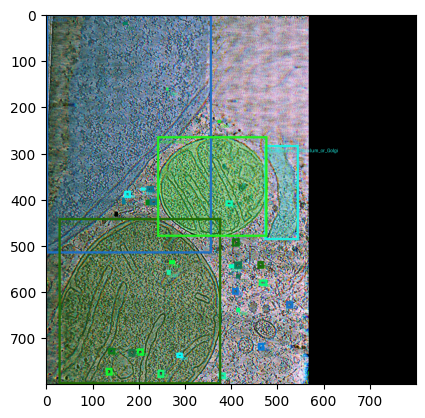

In [ ]:
data = dataset[8]
utils.drawannotation(data["pixel_values"], data["labels"])

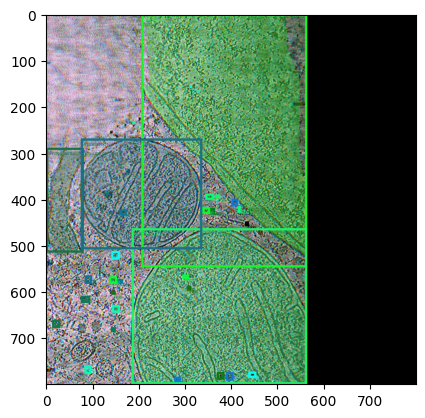

In [ ]:
data = dataset[8]
utils.drawannotation(data["pixel_values"], data["labels"])

In [ ]:
data["labels"]["merge"]["masks"].shape

torch.Size([16, 800, 800])

In [ ]:
for i in range(10000):
    for j in range(10000):
        pass

In [ ]:
data["pixel_values"].shape

torch.Size([3, 800, 800])

In [ ]:
output = model_pretrain(
        pixel_values=data["pixel_values"].unsqueeze(0).float(),
        pixel_mask=data["pixel_mask"].unsqueeze(0).float(),
    )

In [ ]:
_output = output
logits = _output["logits"].squeeze(0)
pred_boxes = _output["pred_boxes"].squeeze(0)
prob = torch.sigmoid(logits)
res = prob > torch.tensor([0.25, 0.25])
res = res.any(dim=1)

In [ ]:
bbox = pred_boxes[res]
bbox = torch.zeros_like(bbox) 
bbox[:, 0] = pred_boxes[res][:, 0] - pred_boxes[res][:, 2] / 2
bbox[:, 1] = pred_boxes[res][:, 1] - pred_boxes[res][:, 3] / 2
bbox[:, 2] = pred_boxes[res][:, 0] + pred_boxes[res][:, 2] / 2
bbox[:, 3] = pred_boxes[res][:, 1] + pred_boxes[res][:, 3] / 2
bbox *= torch.tensor([data["pixel_values"].shape[2], data["pixel_values"].shape[1], data["pixel_values"].shape[2], data["pixel_values"].shape[1]]) 
bbox = bbox.long()

In [ ]:
labels = ["test" for i in range(bbox.shape[0])] 

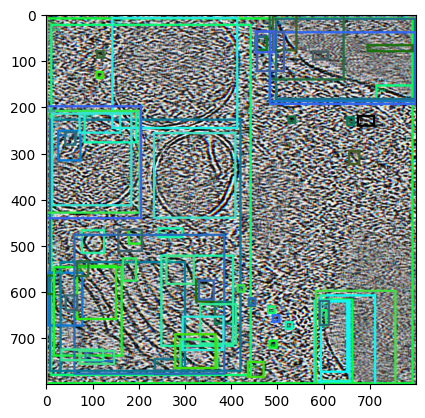

In [ ]:
labels = {"bboxes": bbox, "labels": labels} 
utils.drawannotation(data["pixel_values"], labels)

### test train

In [66]:
model_finetuned = utils.loadModel("/data/transformer_project/transforemer_model/train_data/training/results/conditional_detr/whole_Unet5_0.8", "last.ckpt")

Some weights of ConditionalDetrForObjectDetection were not initialized from the model checkpoint at microsoft/conditional-detr-resnet-50 and are newly initialized because the shapes did not match:
- class_labels_classifier.bias: found shape torch.Size([91]) in the checkpoint and torch.Size([5]) in the model instantiated
- class_labels_classifier.weight: found shape torch.Size([91, 256]) in the checkpoint and torch.Size([5, 256]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/home/feity/anaconda3/envs/pytorch/lib/python3.12/site-packages/torch/nn/modules/transformer.py:307: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(f"enable_nested_tensor is True, but self.use_nested_tensor is False because {why_not_sparsity_fast_path}")
/home/feity/cryoem/u

model at stage  stage 1 + 2 + 3
incompatible parameters ['model.class_labels_classifier.weight', 'model.class_labels_classifier.bias', 'additional_input_layer.layer1.weight', 'additional_input_layer.layer1.bias', 'additional_input_layer.layer2.weight', 'additional_input_layer.layer2.bias', 'gnn.conv1.lin_l.weight', 'gnn.conv1.lin_l.bias', 'gnn.conv1.lin_r.weight', 'gnn.conv2.lin_l.weight', 'gnn.conv2.lin_l.bias', 'gnn.conv2.lin_r.weight', 'gnn.conv3.lin_l.weight', 'gnn.conv3.lin_l.bias', 'gnn.conv3.lin_r.weight', 'gnn.cls_head.0.weight', 'gnn.cls_head.0.bias', 'gnn.cls_head.2.weight', 'gnn.cls_head.2.bias', 'gnn.box_head.0.weight', 'gnn.box_head.0.bias', 'gnn.box_head.2.weight', 'gnn.box_head.2.bias', 'gnn.edge_head.0.weight', 'gnn.edge_head.0.bias', 'gnn.edge_head.2.weight', 'gnn.edge_head.2.bias', 'gnn.edge_head.4.weight', 'cri.weight', 'mask_head.inc.double_conv.0.weight', 'mask_head.inc.double_conv.1.weight', 'mask_head.inc.double_conv.1.bias', 'mask_head.inc.double_conv.3.weight',

/home/feity/cryoem/utils.py:1218: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(os.path.join(path, checkpoint), map_location="cpu")["state_dict"]


incompatible parameters []
finish loading parameters


In [4]:
importlib.reload(modules)
# dataset = modules.CocoDetection(
#                             # "/mnt/panbz/lab/transforemer_model/train_data/training/data/", 
#                             "/data/transformer_project/transforemer_model/train_data/training/data/", 
#                             "/data/transformer_project/transforemer_model/train_data/training/data/annotations/TS_005.pkl", 
#                             # "/mnt/panbz/lab/transforemer_model/train_data/training/data/annotations/train6.pkl", 
#                             # "/data/transformer_project/transforemer_model/train_data/training/data/annotations/train1.pkl",
#                             is_npy=True, filter_class=[3, 4, 7, 12, 14], map_class={"3":0, "4":1, "7":2, "12":3, "14":4}, require_mask=True, transform=utils.getConstantTransform(), add_classname=True, norm="hist", filtermin=5)
                            # is_npy=True, filter_class=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14], require_mask=True, transform=utils.getConstantTransform(), add_classname=True, norm="hist", filtermin=5)
dataset = modules.CocoDetection(
                            "/data/transformer_project/transforemer_model/train_data/training/data/", 
                            "/data/transformer_project/transforemer_model/train_data/training/data/annotations/sllt0039_9.pkl",
                            is_npy=True, filter_class=[3, 4, 7, 12, 14], map_class={"3":0, "4":1, "7":2, "12":3, "14":4}, require_mask=True, transform=utils.getConstantTransform(), add_classname=True, norm="hist",filtermin=5
)

loading annotations into memory...
Done (t=0.01s)
creating index...
index created!


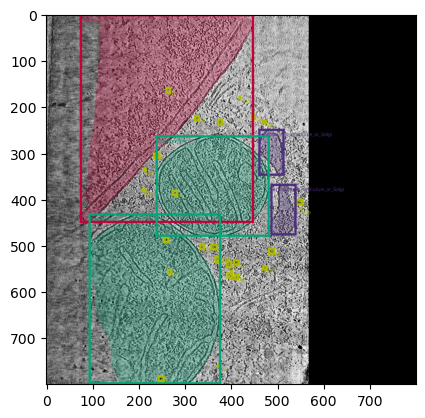

In [64]:
data = dataset[10]
img = data["pixel_values"]
img[0] = img[1]
img[2] = img[1]
utils.drawannotation(img, data["labels"])

In [65]:
data["labels"]["size"]

tensor([800, 568])

In [67]:
model.stage = "stage 1"
output = model_finetuned(
        pixel_values=data["pixel_values"].unsqueeze(0).float(),
        pixel_mask=data["pixel_mask"].unsqueeze(0).float(),
    )

In [68]:
output.pred_boxes

tensor([[[0.6699, 0.8158, 0.0688, 0.1420],
         [0.4705, 0.0692, 0.0320, 0.0318],
         [0.6656, 0.4974, 0.0878, 0.2583],
         ...,
         [0.3136, 0.2815, 0.0196, 0.0179],
         [0.6530, 0.4461, 0.0155, 0.0147],
         [0.0141, 0.3354, 0.0290, 0.1415]]], grad_fn=<SigmoidBackward0>)

In [74]:
_output = output
logits = _output["logits"].squeeze(0)
pred_boxes = _output["pred_boxes"].squeeze(0)
prob = torch.sigmoid(logits)
res = prob > torch.tensor([0.15, 0.15, 0.15, 0.15, 0.15])
res = res.any(dim=1)
bbox = pred_boxes[res]
bbox = torch.zeros_like(bbox) 
bbox[:, 0] = pred_boxes[res][:, 0] - pred_boxes[res][:, 2] / 2
bbox[:, 1] = pred_boxes[res][:, 1] - pred_boxes[res][:, 3] / 2
bbox[:, 2] = pred_boxes[res][:, 0] + pred_boxes[res][:, 2] / 2
bbox[:, 3] = pred_boxes[res][:, 1] + pred_boxes[res][:, 3] / 2
bbox *= torch.tensor([data["pixel_values"].shape[2], data["pixel_values"].shape[1], data["pixel_values"].shape[2], data["pixel_values"].shape[1]]) 
bbox = bbox.long()

51


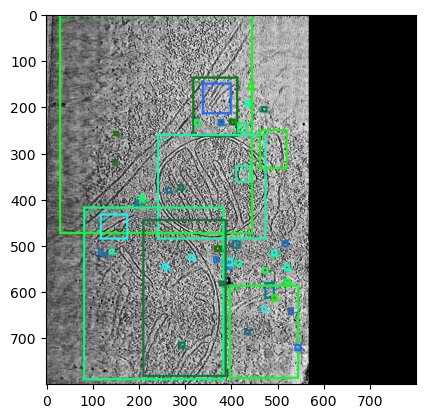

In [75]:
importlib.reload(utils)
labels = ["test" for i in range(bbox.shape[0])]
print(len(labels)) 
labels = {"bboxes": bbox, "labels": labels} 
utils.drawannotation(data["pixel_values"], labels)

In [ ]:
model_finetuned

DetrModel(
  (model): ConditionalDetrForObjectDetection(
    (model): ConditionalDetrModel(
      (backbone): ConditionalDetrConvModel(
        (conv_encoder): ConditionalDetrConvEncoder(
          (model): FeatureListNet(
            (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
            (bn1): ConditionalDetrFrozenBatchNorm2d()
            (act1): ReLU(inplace=True)
            (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
            (layer1): Sequential(
              (0): Bottleneck(
                (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
                (bn1): ConditionalDetrFrozenBatchNorm2d()
                (act1): ReLU(inplace=True)
                (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
                (bn2): ConditionalDetrFrozenBatchNorm2d()
                (drop_block): Identity()
                (act2): ReLU(inpl

### test stage2 dataset

In [ ]:
graph = torch.load("/data/transformer_project/transforemer_model/train_data/training/data/stage2/fold4_TS_005_stage2dataset_stage12_507.pkl") 
retdict = torch.load("/data/transformer_project/transforemer_model/train_data/training/data/stage2/fold4_TS_005_stage2dict_stage12_507.pkl")

/tmp/ipykernel_2143234/2781913261.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  graph = torch.load("/data/transformer_project/transforemer_model/train_data/training/da

In [ ]:
feature = graph.x
edge_index = graph.edge_index 
feature[:5]

tensor([[ 0.3200,  0.2512,  0.4753,  ...,  2.1821, -1.4611, -0.4298],
        [ 0.3200,  0.0310,  0.8261,  ...,  2.1817, -1.5068, -0.4754],
        [ 0.3200,  0.0723,  0.9617,  ...,  2.0695, -1.2034, -0.4880],
        [ 0.3200,  0.3411,  0.4311,  ...,  2.2969, -1.4519, -0.5166],
        [ 0.3200,  0.1326,  0.9921,  ...,  2.0088, -0.9507, -0.3820]])

In [ ]:
t = 4030
need = [] 
for i, j in edge_index.t().tolist():
    # if retdict["sample_mapping"][i] == retdict["sample_mapping"][j]:
    #     continue
    if i == t:
        need.append(j)
    if j == t:
        need.append(i)
need = np.unique(need)
len(need)

2

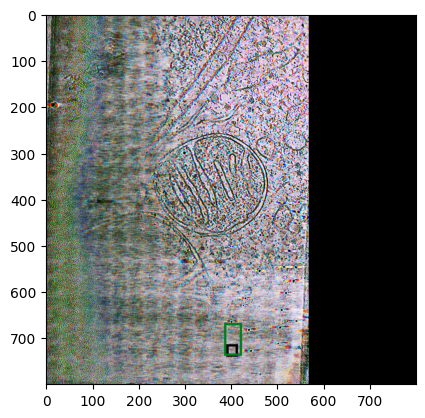

In [ ]:
img = retdict["images"][retdict["sample_mapping"][t]]
bbox = feature[need, 1:5]
box = torch.zeros_like(bbox) 
box[:, 0] = bbox[:, 0] - bbox[:, 2] / 2
box[:, 1] = bbox[:, 1] - bbox[:, 3] / 2
box[:, 2] = bbox[:, 0] + bbox[:, 2] / 2
box[:, 3] = bbox[:, 1] + bbox[:, 3] / 2
box = box*800
labels = ["" for i in range(box.shape[0])]
labels = {"bboxes": box, "labels": labels}

utils.drawannotation(img, labels)

In [ ]:
retdict.keys()

dict_keys(['feature', 'label', 'masks', 'box_mask', 'boxes', 'item_id', 'images', 'pixel_masks', 'sample_mapping'])

In [ ]:
need = []
boxes1 = []
boxes2 = []
labels = []
pos = -1
for i in retdict["sample_mapping"]:
    # if retdict["box_mask"][i]:
    #     pos += 1
    #     boxes1.append(retdict["boxes"][i])
    #     boxes2.append(feature[i][1:5])
    if retdict["sample_mapping"][i] == 12:
        need.append(i)
        if retdict["box_mask"][i]:
            labels.append(retdict["label"][i])
            boxes1.append(retdict["boxes"][i])
            boxes2.append(feature[i][1:5])


In [ ]:
bbox1 = torch.stack(boxes1)
bbox2 = torch.stack(boxes2)

In [ ]:
modules.loss_boxes(bbox2, bbox1, 5)
# bbox = bbox2

tensor(0.7992)

In [ ]:
box = torch.zeros_like(bbox) 
box[:, 0] = bbox[:, 0] - bbox[:, 2] / 2
box[:, 1] = bbox[:, 1] - bbox[:, 3] / 2
box[:, 2] = bbox[:, 0] + bbox[:, 2] / 2
box[:, 3] = bbox[:, 1] + bbox[:, 3] / 2
box = box*800

In [ ]:
labels = ["" for i in range (box.shape[0])]

/home/feity/cryoem/utils.py:102: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  image = torch.tensor(image * 255).type(torch.uint8)
/home/feity/cryoem/utils.py:113: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  annotated_tensor = torch.tensor(annotated_tensor, dtype=torch.uint8)
/home/feity/anaconda3/envs/pytorch/lib/python3.12/site-packages/torchvision/utils.py:225: UserWarning: Argument 'font_size' will be ignored since 'font' is not set.
  warnings.warn("Argument 'font_size' will be ignored since 'font' is not set.")


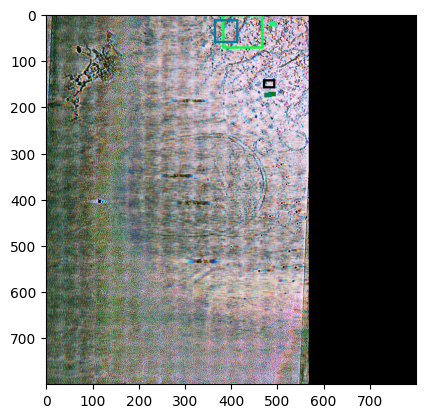

In [ ]:
utils.drawannotation(retdict["images"][15], {"bboxes":box, "labels":labels})

### test stage2

In [ ]:
graph = torch.load("/data/transformer_project/transforemer_model/train_data/training/data/stage2/fold1_sllt0039_9_stage2dataset.pkl") 
retdict = torch.load("/data/transformer_project/transforemer_model/train_data/training/data/stage2/fold1_sllt0039_9_stage2dict.pkl")
model = utils.loadModel("/data/transformer_project/transforemer_model/train_data/training/results/deformable/fold1_stage2_change_simple/", "epoch=27-validate_loss=0.9320-validate_auroc=0.8527.ckpt")

/tmp/ipykernel_21457/1997501964.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  graph = torch.load("/data/transformer_project/transforemer_model/train_data/training/data

model at stage  stage 2
incompatible parameters ['additional_input_layer.layer1.weight', 'additional_input_layer.layer1.bias', 'additional_input_layer.layer2.weight', 'additional_input_layer.layer2.bias', 'gnn.conv1.lin_l.weight', 'gnn.conv1.lin_l.bias', 'gnn.conv1.lin_r.weight', 'gnn.conv2.lin_l.weight', 'gnn.conv2.lin_l.bias', 'gnn.conv2.lin_r.weight', 'gnn.conv3.lin_l.weight', 'gnn.conv3.lin_l.bias', 'gnn.conv3.lin_r.weight', 'gnn.cls_head.2.weight', 'gnn.cls_head.2.bias', 'gnn.box_head.2.weight', 'gnn.box_head.2.bias', 'cri.weight']
finish loading parameters


/home/feity/cryoem/utils.py:941: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(os.path.join(path, checkpoint))["state_dict"]


incompatible parameters []
finish loading parameters


In [ ]:
graph

Data(x=[5908, 266], edge_index=[2, 138028], y=[5908], box_masks=[5908], boxes=[5908, 4], edge_label=[138028], sample_mapping=[5908])

In [ ]:
retdict.keys()

dict_keys(['feature', 'label', 'masks', 'box_mask', 'boxes', 'item_id', 'images', 'pixel_masks', 'sample_mapping'])

In [ ]:
retdict["box_mask"]

tensor([False, False, False,  ..., False, False, False])

In [ ]:
model.stage = "stage 2"
res = model(graph.x, graph.edge_index)
res.keys()

dict_keys(['predict', 'box', 'edge', 'embeddings'])

In [ ]:
res["box"][need]

tensor([[ 4.8578e-01,  2.5075e-01,  5.0722e-02,  4.8486e-02],
        [ 4.1311e-01,  7.0092e-01,  2.7413e-02,  3.1270e-02],
        [ 5.2069e-01,  9.9996e-01,  1.6811e-02,  1.8189e-02],
        [ 5.9582e-01,  2.3724e-01,  4.4105e-02,  3.3173e-02],
        [ 5.5079e-01,  1.0235e+00,  4.7918e-02,  4.2445e-02],
        [ 4.9084e-01,  4.5994e-01,  4.7755e-02,  3.9205e-02],
        [ 5.3578e-01,  9.3985e-01,  3.1679e-02,  1.6369e-02],
        [ 5.9001e-01,  4.3379e-01,  2.4569e-02,  1.1407e-02],
        [ 4.6958e-01,  8.6949e-01,  3.5240e-02,  3.3858e-02],
        [ 5.2758e-01,  2.5519e-01,  4.5438e-02,  3.4869e-02],
        [ 6.1801e-01,  1.6587e-01,  4.2762e-02,  3.2150e-02],
        [ 5.2386e-01,  1.8604e-01,  2.0395e-01,  3.1737e-01],
        [ 3.3910e-01,  5.7721e-01,  1.8659e-02,  7.9247e-03],
        [ 5.5522e-01,  3.6215e-01,  1.6741e-01,  7.8304e-02],
        [ 5.8040e-01,  1.9354e-01,  1.9044e-02,  1.4697e-02],
        [ 5.2720e-01,  1.8408e-01,  5.8342e-02,  6.1200e-02],
        

In [ ]:
res["box"].shape

torch.Size([5908, 4])

In [ ]:
take = 25
need = []
for i in retdict["sample_mapping"]:
    if retdict["sample_mapping"][i] == take:
        need.append(i)
img = retdict["images"][take]

In [ ]:
class E(object):
    pass
r = E()
r.a = 1

In [ ]:
r.logits = res["predict"][need]
r.pred_boxes = res["box"][need]
r.embeddings = res["embeddings"][need]
# r.logits = r.logits.unsqueeze(0)
# r.pred_boxes = r.pred_boxes.unsqueeze(0)

In [ ]:
prob = torch.softmax(res["predict"][need], 1)
# prob
# prob = res["predict"][need]
p = prob > torch.tensor([0.45, 0.6, 0.6, 0.6, 0.6, 1.2])
p = p.any(dim=1)
p

tensor([False,  True, False,  True, False,  True,  True, False, False, False,
        False,  True, False,  True, False, False, False, False, False,  True,
        False, False, False,  True,  True,  True, False,  True, False, False,
        False, False,  True,  True, False, False, False, False, False, False,
        False, False,  True,  True, False,  True, False,  True, False, False,
        False, False, False, False,  True, False, False, False,  True, False,
         True, False,  True, False, False, False, False, False, False, False,
        False, False, False, False, False,  True, False,  True, False,  True,
        False, False, False, False, False, False, False, False,  True, False,
        False, False, False, False, False, False, False, False,  True, False,
         True,  True, False, False, False, False, False,  True,  True,  True,
         True, False, False, False, False, False,  True, False, False, False,
        False, False, False,  True,  True,  True, False, False, 

In [ ]:
# pred_boxes = graph.x[need, 1:5]#res["box"][need]
pred_boxes = res["box"][need]
bbox = pred_boxes[p]
bbox = torch.zeros_like(bbox) 
bbox[:, 0] = pred_boxes[p][:, 0] - pred_boxes[p][:, 2] / 2
bbox[:, 1] = pred_boxes[p][:, 1] - pred_boxes[p][:, 3] / 2
bbox[:, 2] = pred_boxes[p][:, 0] + pred_boxes[p][:, 2] / 2
bbox[:, 3] = pred_boxes[p][:, 1] + pred_boxes[p][:, 3] / 2
bbox *= torch.tensor([data["pixel_values"].shape[2], data["pixel_values"].shape[1], data["pixel_values"].shape[2], data["pixel_values"].shape[1]]) 
bbox = bbox.long()

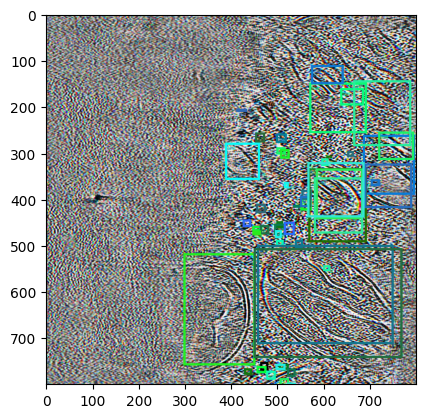

In [ ]:
labels = ["test" for i in range(bbox.shape[0])] 
labels = {"bboxes": bbox, "labels": labels} 
utils.drawannotation(img, labels)

In [ ]:
target_sizes = [(800, 800)]
results = utils.postSegmentationTreatment(r, 0.1, target_sizes, mask_threshold=None, style="None")
result = results[0]

ValueError: Make sure that you pass in as many target sizes as the batch dimension of the logits

In [ ]:
keep = utils.bbnms(0.2, result["boxes"], result["scores"], result["labels"])
for i in result:
    result[i] = result[i][keep]

In [ ]:
retdict.keys()

dict_keys(['feature', 'label', 'masks', 'box_mask', 'boxes', 'item_id', 'images', 'pixel_masks', 'sample_mapping'])

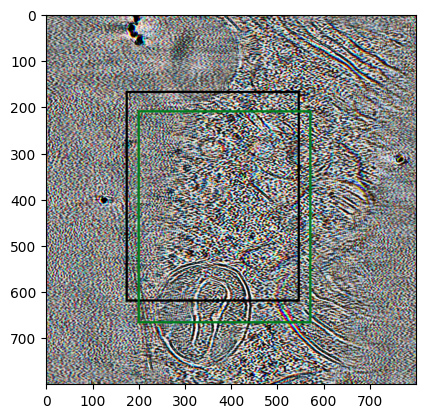

In [ ]:
img = retdict["images"][20]
t = utils.toTarget(result, img.shape[1:])
# t["masks"] = output > 0.5
importlib.reload(utils)
utils.drawannotation(img.cpu(), t)

In [ ]:
model = utils.loadModel("/mnt/panbz/lab/transforemer_model/train_data/training/results/deformable/fold6_test_with_crop", "last.ckpt") 
for i in ["TS_005.pkl", "TS_023.pkl", "TS_031.pkl", "sllt0039_9.pkl", "sllt0051_9.pkl", "sllt0081_9.pkl"]:
    dataset = modules.CocoTraverse("/mnt/panbz/lab/transforemer_model/train_data/training/data/", 
                            "/mnt/panbz/lab/transforemer_model/train_data/training/data/annotations/"+i,
                            is_npy=True, filter_class={"all":[1,2,3,4,5,6,7,8,9,10,11,12,13]}, single_class={"all":False}, add_classname=True, maxsize=800, require_mask=True) 

    retdict = utils.buildStage2(model, dataset, (800, 800), 0.2, model_names=["all"], has_none=False, single=True)
    d = utils.convertStage2Dataset(retdict)
    torch.save(d, "/mnt/panbz/lab/transforemer_model/train_data/training/results_0.2/deformable/fold6_test_with_crop/res/"+i.split(".")[0]+"_stage2dataset.pkl")
    torch.save(retdict, "/mnt/panbz/lab/transforemer_model/train_data/training/results_0.2/deformable/fold6_test_with_crop/res/"+i.split(".")[0]+"_stage2.pkl")

In [ ]:
graph = torch.load("/mnt/panbz/lab/transforemer_model/train_data/training/results/deformable/fold6/res/TS_005_stage2dataset.pkl") 
retdict = torch.load("/mnt/panbz/lab/transforemer_model/train_data/training/results/deformable/fold6/res/TS_005_stage2.pkl")
model = utils.loadModel("/mnt/panbz/lab/transforemer_model/train_data/training/results/deformable/fold6_stage2", "epoch=124-validate_loss=1.1173-validate_acc=0.7607.ckpt")

/tmp/ipykernel_34830/1695539048.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  graph = torch.load("/mnt/panbz/lab/transforemer_model/train_data/training/results/deforma

model at stage  stage 2


/home/feity/cryoem/utils.py:471: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  t = torch.load(configs["model"]["load"], map_location="cpu")
/home/feity/cryoem/utils.py:852: 

In [ ]:
retdict["images"][15].shape

torch.Size([3, 800, 800])

In [ ]:
retdict.keys()

dict_keys(['feature', 'label', 'masks', 'box_mask', 'boxes', 'item_id', 'images', 'sample_mapping'])

In [ ]:
model.stage = "stage 2"
res = model(graph.x, graph.edge_index)
res.keys()

dict_keys(['predict', 'box', 'edge', 'embeddings'])

In [ ]:
need = []
for i in retdict["sample_mapping"]:
    if retdict["sample_mapping"][i] == 16:
        need.append(i)

In [ ]:
graph.edge_index.shape

torch.Size([2, 25882])

In [ ]:
class E(object):
    pass
r = E()

In [ ]:
r.logits = res["predict"][need]
r.pred_boxes = res["box"][need]
r.embeddings = res["embeddings"][need]

In [ ]:
r.logits = r.logits.unsqueeze(0)
r.pred_boxes = r.pred_boxes.unsqueeze(0)
r.embeddings.shape

torch.Size([50, 272])

In [ ]:
target_sizes = [(800, 800)]
results = utils.postSegmentationTreatment(r, 0.5, target_sizes,mask_threshold=None, style="None")
result = results[0]

In [ ]:
keep = utils.bbnms(0.2, result["boxes"], result["scores"], result["labels"])
for i in result:
    result[i] = result[i][keep]

/home/feity/anaconda3/envs/pytorch/lib/python3.12/site-packages/torchvision/utils.py:225: UserWarning: Argument 'font_size' will be ignored since 'font' is not set.
  warnings.warn("Argument 'font_size' will be ignored since 'font' is not set.")


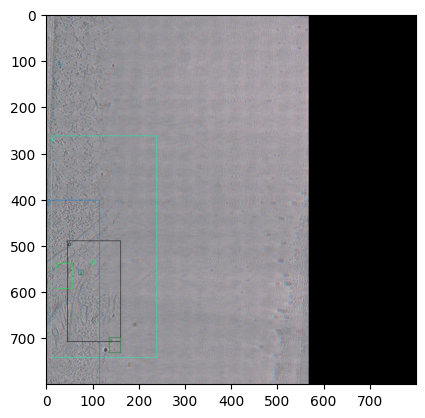

In [ ]:
img = retdict["images"][16]
t = utils.toTarget(result, img.shape[1:])
# t["masks"] = output > 0.5
img = img.cpu().numpy() 
img = (img*255).astype(int)
importlib.reload(utils)
utils.drawannotation(img, t)

### test mask

In [43]:
model = utils.loadModel("/data/transformer_project/transforemer_model/train_data/training/results/conditional_detr/train_mask_0.2", "epoch=49-total_validate_mask_auroc=0.9816.ckpt")

Some weights of ConditionalDetrForObjectDetection were not initialized from the model checkpoint at microsoft/conditional-detr-resnet-50 and are newly initialized because the shapes did not match:
- class_labels_classifier.bias: found shape torch.Size([91]) in the checkpoint and torch.Size([5]) in the model instantiated
- class_labels_classifier.weight: found shape torch.Size([91, 256]) in the checkpoint and torch.Size([5, 256]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/home/feity/anaconda3/envs/pytorch/lib/python3.12/site-packages/torch/nn/modules/transformer.py:307: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(f"enable_nested_tensor is True, but self.use_nested_tensor is False because {why_not_sparsity_fast_path}")
/home/feity/cryoem/u

model at stage  stage mask
incompatible parameters []
finish loading parameters


/home/feity/cryoem/utils.py:1218: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(os.path.join(path, checkpoint), map_location="cpu")["state_dict"]


incompatible parameters []
finish loading parameters


In [22]:
path = "/data/transformer_project/transforemer_model/train_data/training/results/conditional_detr/dummy_test_mask"
with open(os.path.join(path, "config.json"), "r") as f:
    configs = json.load(f)
ds = utils.get_stageMask_dataset(configs)


/home/feity/cryoem/utils.py:1190: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  data = torch.load(i)


In [47]:
dl = ds.val_dataloader()
t = 0
for i in dl:
    t += 1
    if t == 10:
        break
    # break

In [48]:
i[0].shape

torch.Size([8, 3, 800, 800])

In [49]:
model.stage = "stage mask"
outputs = model(pixel_values=i[0], stage_2_embeds=i[1])
outputs.shape

torch.Size([8, 800, 800])

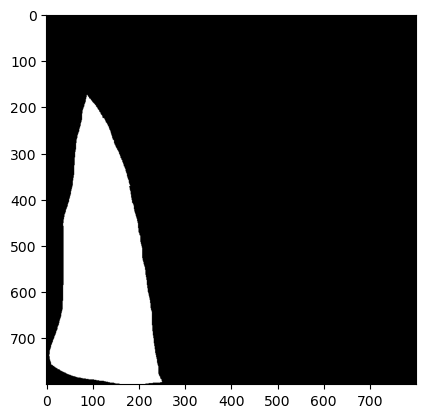

In [50]:
plt.imshow(i[2][1], cmap="gray")

In [51]:
import torchmetrics 
auroc = torchmetrics.AUROC(task="binary")
auroc(outputs[1], i[2][1])

tensor(0.9830)

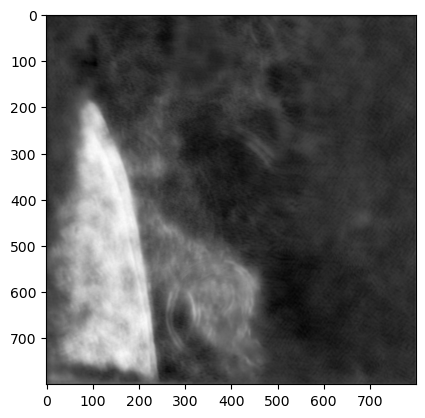

In [52]:
# outputs = torch.sigmoid(outputs)
plt.imshow((outputs[1]).detach(), cmap="gray")

### test stage 123 dataset

In [42]:
path = "/data/transformer_project/transforemer_model/train_data/training/results/conditional_detr/fold6"
with open(os.path.join(path, "config.json"), "r") as f:
    configs = json.load(f)
ds = utils.get_stage12_dataset(configs)


loading annotations into memory...
Done (t=0.03s)
creating index...
index created!
using batch size  5
loading annotations into memory...
Done (t=0.02s)
creating index...
index created!
using batch size  5
loading annotations into memory...
Done (t=0.01s)
creating index...
index created!
using batch size  5
loading annotations into memory...
Done (t=0.01s)
creating index...
index created!
using batch size  5
loading annotations into memory...
Done (t=0.00s)
creating index...
index created!
using batch size  5
loading annotations into memory...
Done (t=0.01s)
creating index...
index created!
using batch size  5


In [43]:
dl = ds.train_dataloader()
cnt = 1
for i, j in enumerate(dl):
    cnt += 1
    if cnt == 5:    
        break

In [48]:
dl = ds.val_dataloader()
j = dl.dataset[6]
# cnt = 1
# for i, j in enumerate(dl):
#     cnt += 1
#     if cnt == 2:    
#         break

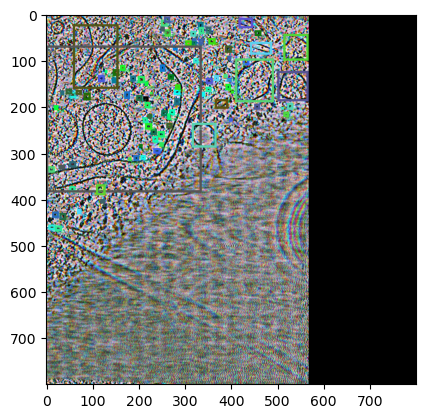

In [49]:
i = 0
img = j["pixel_values"][i]
label = j["labels"][i]
label["names"] = ["test" for i in range(label["boxes"].shape[0])]
utils.drawannotation(img, label)

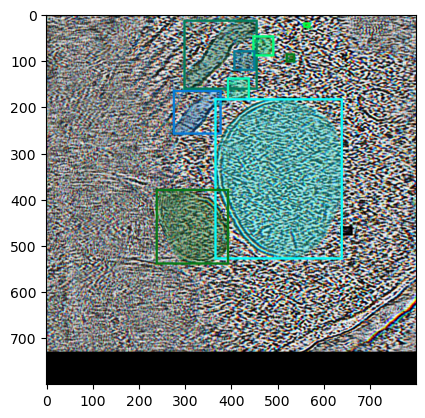

In [39]:
i = 2
img = j[0]["pixel_values"][i]
label = j[0]["labels"][i]
label["names"] = ["test" for i in range(label["boxes"].shape[0])]
utils.drawannotation(img, label)

### get pretrain dataset

In [3]:
path = "/data/transformer_project/transforemer_model/train_data/training/results/conditional_detr/pretrain/"
with open(os.path.join(path, "config.json"), "r") as f:
    configs = json.load(f)
ds = utils.get_stage1_dataset(configs)


loading annotations into memory...
Done (t=1.14s)
creating index...
index created!
loading annotations into memory...
Done (t=0.20s)
creating index...
index created!


In [40]:
dl = ds.val_dataloader()
j = dl.dataset[52]

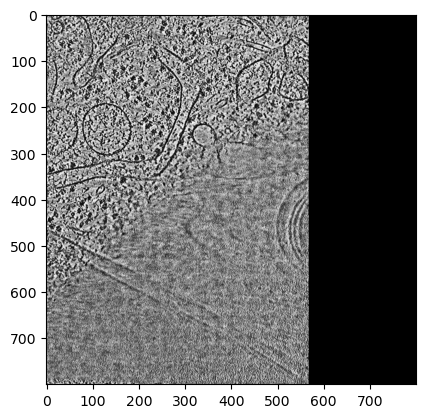

In [50]:
plt.imshow(j["pixel_values"][0][1], cmap="gray")
plt.savefig("./temp/test2.png", dpi=300)

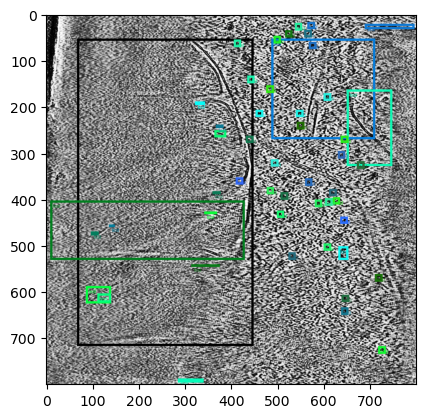

In [16]:
i = 1
img = j["pixel_values"][[i]]
label = j["labels"]
label["names"] = ["test" for i in range(label["boxes"].shape[0])]
utils.drawannotation(img, label)